# 01. Bias Detection in Machine Learning Models

## 📚 Learning Objectives

By completing this notebook, you will:
- Detect bias in datasets and model outputs
- Use metrics and visualizations to assess fairness
- Identify sources of discriminatory impact

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 3, lesson 01 "Logistic Regression and Classification Metrics" — the confusion matrix you built there, now computed separately for each group.

**Used later in:** Course 08 (AIAT 122) — Unit 4, lesson 04 "Ethical Concerns: Bias, Fairness, Interpretability" — accuracy by group, measured on a deep model.

---
> **Word-sense reminder.** Every use of "bias" in this unit is the **fairness** sense. It has nothing
> to do with the bias term `b` in `w·x + b` (Course 01, AIAT 111, Unit 4) or with bias in the
> bias–variance trade-off (Course 04, AIAT 114, Unit 2). Unit 1, lesson 03 of this course sets the
> two apart in full; `docs/GLOSSARY.md` holds the ruling.

# 01. Bias Detection in Machine Learning Models

## 🚨 THE PROBLEM: AI Systems Are Making Unfair Decisions

**Remember the COMPAS case study from Unit 1?**

We discovered that COMPAS showed:
- Higher false positive rates for Black defendants
- Higher false negative rates for White defendants
- Racial bias in risk predictions

**The Problem**: We understand ethics foundations, but **AI systems show bias. How do we detect it?**

**We've learned:**
- ✅ How to identify ethical issues (frameworks from Unit 1)
- ✅ How bias manifests in real systems (COMPAS case study)
- ✅ That bias is a serious ethical problem

**But we haven't learned:**
- ❌ How to **detect** bias in AI systems
- ❌ How to **measure** bias quantitatively
- ❌ How to **identify** where bias exists

**We need bias detection tools** to:
1. Find where bias exists in our models
2. Measure how unfair our systems are
3. Identify which groups are being discriminated against

**This notebook solves that problem** by teaching you bias detection metrics and tools!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Unit 1: Foundations of AI Ethics** - You need to understand ethical frameworks and case studies!
- ✅ **Basic Python knowledge**: Functions, dictionaries, data manipulation
- ✅ **Basic ML knowledge**: Classification, train/test split, confusion matrices
- ✅ **Understanding of bias**: What is algorithmic bias? (from Unit 1 case studies)

**If you haven't completed these**, you might struggle with:
- Understanding why bias detection matters
- Knowing which metrics to use for bias detection
- Interpreting bias detection results

---

## 🔗 Where This Notebook Fits

**This is the FIRST example in Unit 2** - it addresses the problem from Unit 1!

**Why this example FIRST?**
- **Before** you can mitigate bias, you need to detect it (addresses the problem!)
- **Before** you can ensure fairness, you need to measure it
- **Before** you can fix problems, you need to identify them

**Builds on**: 
- 📓 Unit 1: Foundations (we identified bias as a problem - now we learn to detect it!)

**Leads to**: 
- 📓 Example 2: Bias Mitigation (once we detect bias, we learn to fix it!)
- 📓 Example 3: Fair Representation (ensuring fair representation in data)
- 📓 Example 4: Bias Case Studies (analyzing real bias cases)
- 📓 Example 5: Fair AI Development (building fair AI systems)

**Why this order?**
1. Detection **addresses the problem** from Unit 1 (we need to detect bias!)
2. Detection provides **measurement tools** (needed before mitigation)
3. Detection teaches **what bias looks like** (critical for understanding)

---

## The Story: Finding the Problem Before Fixing It

Imagine you're a doctor diagnosing a patient. **Before** you can treat an illness, you need to diagnose it - run tests, check symptoms, identify the problem. **After** diagnosis, you can prescribe the right treatment!

Same with AI bias: **Before** we can fix bias, we need to detect it - measure fairness metrics, check for disparities, identify where bias exists. **After** detection, we can apply the right mitigation strategies!

---

## Why Bias Detection Matters

Bias detection is essential for ethical AI:
- **Identify Problems**: Find where bias exists in your models
- **Measure Fairness**: Quantify how fair (or unfair) your system is
- **Track Progress**: Monitor if bias mitigation efforts are working
- **Ensure Compliance**: Meet fairness requirements and regulations
- **Build Trust**: Demonstrate commitment to fairness

## Learning Objectives
1. Understand different types of bias in ML models
2. Learn fairness metrics (demographic parity, equalized odds)
3. Detect bias using statistical measures
4. Visualize bias in model predictions
5. Interpret bias detection results
6. Understand when to use different fairness metrics

## 📌 The case: an audit that started by adding one grouping column

**Obermeyer, Powers, Vogeli & Mullainathan, *Science* 366:447–453 (2019).**

A commercial risk-prediction algorithm — the kind US hospitals and insurers apply to roughly
**200 million people a year** — was used to select patients for extra care-management
support. The vendor never fed it race. By every accuracy number the vendor reported, it was
working.

The researchers did the one thing this notebook is about to teach: they **grouped the
model's output by race and compared health at the same score**. At any given risk score,
**Black patients were substantially sicker** than white patients with the same score. The
system was quietly rationing care away from the people who needed it most.

The cause was not a coefficient, and not a missing fairness library. It was the **label**.
The algorithm predicted *health-care cost*, because cost data is clean, complete and cheap
to obtain — but less money is spent on Black patients with the same illness, so **cost is a
biased proxy for illness**. Predicting the proxy almost perfectly produced a system that
under-served the sicker group. Rebuilding it against a direct measure of illness raised the
share of Black patients flagged for extra help from **17.7 % to 46.5 %**, removing about
**84 %** of the disparity.

**The WHY — what goes wrong without detection.** Nobody at that company was hiding anything.
The bias was invisible for years because **nobody had grouped the output and looked**. That
is the entire content of this notebook: an aggregate accuracy number is structurally
incapable of seeing a group disparity, and a model that never received a protected
attribute is not thereby innocent of using one. The disparity you are about to measure on
891 real Titanic passengers is found with exactly the same three lines of pandas that found
this one.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `load("titanic")` - the real Titanic passenger manifest
  (891 real passengers; `Age` has 177 genuine missing values, `Embarked` has 2).
- `Sex` is the protected attribute we audit; `Pclass` is a real socio-economic attribute.

**Outputs:** What you'll see when you run the cells

- The real survival gap by sex and by ticket class
- Demographic parity, equalized odds and per-group accuracy for a trained model
- Charts comparing the historical record against the model's predictions

---

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - datasets are loaded by NAME, never by file path.")


Data loader ready - datasets are loaded by NAME, never by file path.


In [2]:
# Step 1: Import necessary libraries
# These libraries help us detect bias in machine learning models

import matplotlib.pyplot as plt  # For creating visualizations: Charts, graphs, bias visualizations
import numpy as np  # For numerical operations: Arrays, calculations, random number generation
import pandas as pd  # For data manipulation: DataFrames, data analysis
from sklearn.model_selection import train_test_split  # For splitting data: Separate training and testing sets
from sklearn.ensemble import RandomForestClassifier  # For ML model: Classification algorithm
from sklearn.metrics import confusion_matrix, classification_report  # For model evaluation: Performance metrics
import seaborn as sns  # For statistical visualizations: Heatmaps, advanced plots
import os  # For file operations: Saving images

# Configure matplotlib settings: Set default figure size and font size for better visualizations
plt.rcParams['font.size'] = 10  # Font size: Make text readable (10pt is good for most displays)
plt.rcParams['figure.figsize'] = (14, 8)  # Figure size: 14 inches wide, 8 inches tall (good for detailed charts)

print(" Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - matplotlib/seaborn: Create visualizations (bias charts, heatmaps)")
print("   - numpy: Numerical operations (arrays, calculations)")
print("   - pandas: Data manipulation (DataFrames, analysis)")
print("   - sklearn: Machine learning (models, metrics, data splitting)")
print("   - os: File operations (saving images)")


 Libraries imported successfully!

📚 What each library does:
   - matplotlib/seaborn: Create visualizations (bias charts, heatmaps)
   - numpy: Numerical operations (arrays, calculations)
   - pandas: Data manipulation (DataFrames, analysis)
   - sklearn: Machine learning (models, metrics, data splitting)
   - os: File operations (saving images)


## Part 2: Meeting Real Bias in Real Data

### 📚 Prerequisites (What You Need First)
- **Library imports** (from Part 1) - Understanding data manipulation and ML tools
- **Understanding of bias** (from Unit 1) - Knowing what bias is

### 🔗 Relationship: What This Builds On
This loads a REAL historical dataset in which a real, documented disparity exists,
so we practice detection on evidence rather than on invented people.
- Builds on: Data manipulation skills, understanding of bias
- Shows: How disparity actually looks in a real record

### 📖 The Story
**Before the data**: We need a case where a group difference genuinely exists.
**After the data**: We have the Titanic passenger manifest - 891 real people, a real
life-and-death decision ("who got a place in a lifeboat"), and a survival gap between
women and men so large that no simulation is needed to see it.

### ⚠️ A note on studying real harm
These are real passengers who really died. We study the record because fairness
work on invented data teaches invented lessons: real data brings missing values,
confounded attributes and messy results that a simulation quietly hides.

In [3]:
# Step 2: Load the REAL Titanic passenger manifest
# 891 real passengers, a real decision (who was placed in a lifeboat), and a real
# survival gap by sex - this is the disparity we will learn to detect and measure.

print("\n" + "="*80)
print("📊 LOADING REAL DATA: THE TITANIC PASSENGER MANIFEST")
print("="*80)

# Read the real manifest. 'Survived' is the outcome, 'Sex' is our protected
# attribute, and 'Pclass' (ticket class) is a real socio-economic attribute.
df = load("titanic")
print(f"Loaded {len(df)} real passenger records with {df.shape[1]} columns")

# Real data arrives incomplete - report the missingness honestly before touching it.
print("\nReal missing values (this is what real data looks like):")
missing = df.isna().sum()
print(missing[missing > 0].to_string())

# Impute the two columns we need: median age, most common port of embarkation.
# We record what we did - silent imputation is itself an ethical failure.
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(embarked_mode)
print(f"\nImputed Age with the median ({age_median:.1f}) and Embarked with "
      f"the mode ('{embarked_mode}').")

# The protected attribute we will audit. We keep the dataset's own labels.
df['group'] = df['Sex']

print("\nSurvival rate by sex (the REAL disparity in the historical record):")
for group in sorted(df['group'].unique()):
    sub = df[df['group'] == group]
    rate = sub['Survived'].mean()
    print(f"  {group:<8}: {rate:.3f} ({rate*100:.1f}%)  n={len(sub)}")
gap = (df.groupby('group')['Survived'].mean().max()
       - df.groupby('group')['Survived'].mean().min())
print(f"\n  Survival gap between the two groups: {gap:.3f} ({gap*100:.1f} points)")

print("\nSurvival rate by ticket class (a real socio-economic attribute):")
for pclass, rate in df.groupby('Pclass')['Survived'].mean().items():
    print(f"  Class {pclass}: {rate:.3f} ({rate*100:.1f}%)")

print("\n⚠️  IMPORTANT - what this gap is and is not:")
print("   'Women and children first' was the stated evacuation policy, so part of")
print("   this gap reflects a deliberate rule, not a hidden prejudice. Real data is")
print("   CONFOUNDED like this. A fairness metric can only tell you THAT outcomes")
print("   differ; deciding whether that difference is justified is a human judgment.")
print("   That distinction is the whole reason ethics sits alongside the metrics.")


📊 LOADING REAL DATA: THE TITANIC PASSENGER MANIFEST
titanic: full file, 891 rows.
Loaded 891 real passenger records with 12 columns

Real missing values (this is what real data looks like):
Age         177
Cabin       687
Embarked      2

Imputed Age with the median (28.0) and Embarked with the mode ('S').

Survival rate by sex (the REAL disparity in the historical record):
  female  : 0.742 (74.2%)  n=314
  male    : 0.189 (18.9%)  n=577

  Survival gap between the two groups: 0.553 (55.3 points)

Survival rate by ticket class (a real socio-economic attribute):
  Class 1: 0.630 (63.0%)
  Class 2: 0.473 (47.3%)
  Class 3: 0.242 (24.2%)

⚠️  IMPORTANT - what this gap is and is not:
   'Women and children first' was the stated evacuation policy, so part of
   this gap reflects a deliberate rule, not a hidden prejudice. Real data is
   CONFOUNDED like this. A fairness metric can only tell you THAT outcomes
   differ; deciding whether that difference is justified is a human judgment.
   T

## Part 3: Detecting Bias with Fairness Metrics

### 📚 Prerequisites (What You Need First)
-  **Biased data generated** (from Part 2) - Understanding the dataset with known bias
-  **Understanding of fairness** - Knowing what fairness means

### 🔗 Relationship: What This Builds On
This is where we actually detect the bias we created!
- Builds on: Biased dataset, understanding of fairness metrics
- Shows: How to measure and detect bias

### 📖 The Story
**Before detection**: We have biased data but don't know how to measure it.
**After detection**: We can quantify bias using fairness metrics and see exactly where it exists!

---

## Step 3: Calculate Fairness Metrics

**BEFORE**: We have data but don't know how to measure bias.

**AFTER**: We'll calculate fairness metrics (demographic parity, equalized odds) to detect bias!

**Why fairness metrics?** They provide:
- Quantitative measures of bias
- Standard ways to compare groups
- Clear thresholds for what's "fair"

In [4]:
# Step 3: Define fairness metric functions
# These quantify disparity: demographic parity and equalized odds

def calculate_demographic_parity(test_df):
    """
    Demographic parity: does each group receive positive predictions at the
    same rate?  Returns per-group positive prediction rates and the disparity
    (max rate - min rate).  A disparity above ~0.1 is a common warning sign.
    """
    rates = test_df.groupby('group')['predicted'].mean().to_dict()
    disparity = max(rates.values()) - min(rates.values())
    return rates, disparity

def calculate_equalized_odds(test_df):
    """
    Equalized odds: does the model make the same KINDS of errors for each
    group?  Compares true positive rate (TPR) and false positive rate (FPR)
    across groups.  Returns per-group {TPR, FPR} plus TPR and FPR disparities.
    """
    results = {}
    for group, gd in test_df.groupby('group'):
        tp = ((gd['Survived'] == 1) & (gd['predicted'] == 1)).sum()
        fn = ((gd['Survived'] == 1) & (gd['predicted'] == 0)).sum()
        fp = ((gd['Survived'] == 0) & (gd['predicted'] == 1)).sum()
        tn = ((gd['Survived'] == 0) & (gd['predicted'] == 0)).sum()
        results[group] = {'TPR': tp / max(tp + fn, 1),
                          'FPR': fp / max(fp + tn, 1),
                          'accuracy': (tp + tn) / max(len(gd), 1),
                          'n': len(gd)}
    tprs = [m['TPR'] for m in results.values()]
    fprs = [m['FPR'] for m in results.values()]
    return results, max(tprs) - min(tprs), max(fprs) - min(fprs)

print("Fairness metric functions defined:")
print("  - calculate_demographic_parity: compares positive prediction rates")
print("  - calculate_equalized_odds: compares TPR/FPR (and accuracy) across groups")

Fairness metric functions defined:
  - calculate_demographic_parity: compares positive prediction rates
  - calculate_equalized_odds: compares TPR/FPR (and accuracy) across groups


## Part 4: Training Model and Detecting Bias

### 📚 Prerequisites (What You Need First)
- **Fairness metrics** (from Part 3) - Understanding how to calculate bias
- **Biased data** (from Part 2) - Having data to analyze

### 🔗 Relationship: What This Builds On
This trains a model and uses our fairness metrics to detect bias!
- Builds on: Fairness metric functions, biased dataset
- Shows: How to detect bias in a trained model

### 📖 The Story
**Before training**: We have data and metrics but no model to analyze.
**After training**: We have a trained model and can detect bias in its predictions!

In [5]:
# Step 4: Train a machine learning model and detect bias in its predictions
# This shows how disparity in real historical data flows into a model's predictions

print("\n" + "="*80)
print("🤖 TRAINING MODEL AND DETECTING BIAS")
print("="*80)

def train_and_analyze_bias(df):
    """Train a Random Forest and analyze its predictions with fairness metrics."""
    # Train on the NON-protected features only - 'Sex' is deliberately excluded.
    # This is the classic "fairness through unawareness" attempt: hide the
    # protected attribute and hope the model becomes fair. Watch what happens.
    X = pd.get_dummies(df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']],
                       columns=['Embarked'], drop_first=True)
    y = df['Survived']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    # Fit a standard classifier exactly the way a naive team would - no fairness steps.
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    print("Model trained successfully!")
    y_pred = model.predict(X_test)
    # Assemble one test table holding truth, prediction, and group side by side -
    # fairness metrics need all three to compare outcomes across groups.
    test_df = X_test.copy()
    test_df['Survived'] = y_test.values
    test_df['predicted'] = y_pred
    test_df['group'] = df.loc[X_test.index, 'group'].values
    # Score the predictions with both fairness metrics defined in Step 3.
    parity_rates, parity_disparity = calculate_demographic_parity(test_df)
    equalized_odds, tpr_disparity, fpr_disparity = calculate_equalized_odds(test_df)
    return (test_df, model, parity_rates, parity_disparity,
            equalized_odds, tpr_disparity, fpr_disparity)

(test_df, model, parity_rates, parity_disparity,
 equalized_odds, tpr_disparity, fpr_disparity) = train_and_analyze_bias(df)

overall_acc = (test_df['Survived'] == test_df['predicted']).mean()
print(f"Overall test accuracy: {overall_acc:.3f} on {len(test_df)} held-out passengers")

print("\n📊 BIAS DETECTION RESULTS")
print("="*80)
print("\n1. Demographic Parity")
print("-" * 60)
for group, rate in parity_rates.items():
    print(f"  {group}: {rate:.3f} ({rate*100:.1f}%)")
print(f"\n  Disparity: {parity_disparity:.3f}")
if parity_disparity > 0.1:
    print("  ⚠️  HIGH DISPARITY - Potential bias detected!")
    print("  Note: the model NEVER SAW 'Sex'. It reconstructed the group split from")
    print("  correlated features (fare, class, family size). This is PROXY")
    print("  DISCRIMINATION - and it is why deleting a protected column is not a fix.")
else:
    print("  Low disparity - Fair from demographic parity perspective")

print("\n2. Equalized Odds")
print("-" * 60)
for group, metrics in equalized_odds.items():
    print(f"  {group} (n={metrics['n']}):")
    print(f"    TPR: {metrics['TPR']:.3f}")
    print(f"    FPR: {metrics['FPR']:.3f}")
    print(f"    Accuracy: {metrics['accuracy']:.3f}")
print(f"\n  TPR Disparity: {tpr_disparity:.3f}")
print(f"  FPR Disparity: {fpr_disparity:.3f}")
if tpr_disparity > 0.1 or fpr_disparity > 0.1:
    print("  ⚠️  HIGH DISPARITY - Bias in equalized odds!")
else:
    print("  Low disparity - Fair from equalized odds perspective")

# A third view the real data forces on us: per-group ACCURACY.
accs = {g: m['accuracy'] for g, m in equalized_odds.items()}
worst = min(accs, key=accs.get); best = max(accs, key=accs.get)
print("\n3. Per-Group Accuracy (the metric real data made unavoidable)")
print("-" * 60)
print(f"  Best served : {best} ({accs[best]:.3f})")
print(f"  Worst served: {worst} ({accs[worst]:.3f})")
print(f"  Accuracy gap: {accs[best] - accs[worst]:.3f}")
print("  A model can look acceptable overall while being distinctly worse for")
print("  one group. Always report metrics PER GROUP, never only in aggregate.")


🤖 TRAINING MODEL AND DETECTING BIAS
Model trained successfully!
Overall test accuracy: 0.672 on 268 held-out passengers

📊 BIAS DETECTION RESULTS

1. Demographic Parity
------------------------------------------------------------
  female: 0.443 (44.3%)
  male: 0.316 (31.6%)

  Disparity: 0.128
  ⚠️  HIGH DISPARITY - Potential bias detected!
  Note: the model NEVER SAW 'Sex'. It reconstructed the group split from
  correlated features (fare, class, family size). This is PROXY
  DISCRIMINATION - and it is why deleting a protected column is not a fix.

2. Equalized Odds
------------------------------------------------------------
  female (n=97):
    TPR: 0.529
    FPR: 0.222
    Accuracy: 0.598
  male (n=171):
    TPR: 0.576
    FPR: 0.254
    Accuracy: 0.713

  TPR Disparity: 0.047
  FPR Disparity: 0.031
  Low disparity - Fair from equalized odds perspective

3. Per-Group Accuracy (the metric real data made unavoidable)
------------------------------------------------------------
  Be

## Part 5: Visualizing Bias

### 📚 Prerequisites (What You Need First)
- ✅ **Bias detection results** (from Part 4) - Having fairness metrics calculated
- ✅ **Visualization libraries** (from Part 1) - Understanding matplotlib/seaborn

### 🔗 Relationship: What This Builds On
This visualizes the bias we detected!
- Builds on: Bias detection results, visualization skills
- Shows: Visual representation of bias metrics

### 📖 The Story
**Before visualization**: We have numbers but can't easily see the bias.
**After visualization**: We can see bias clearly in charts and graphs!

---

## Step 5: Visualize Bias Detection Results

**BEFORE**: We have bias metrics but no visual representation.

**AFTER**: We'll create charts showing demographic parity, equalized odds, and confusion matrices!

**Why visualize?** Visual representation helps us:
- See bias patterns clearly
- Compare groups easily
- Communicate findings to others
- Identify which groups are most affected

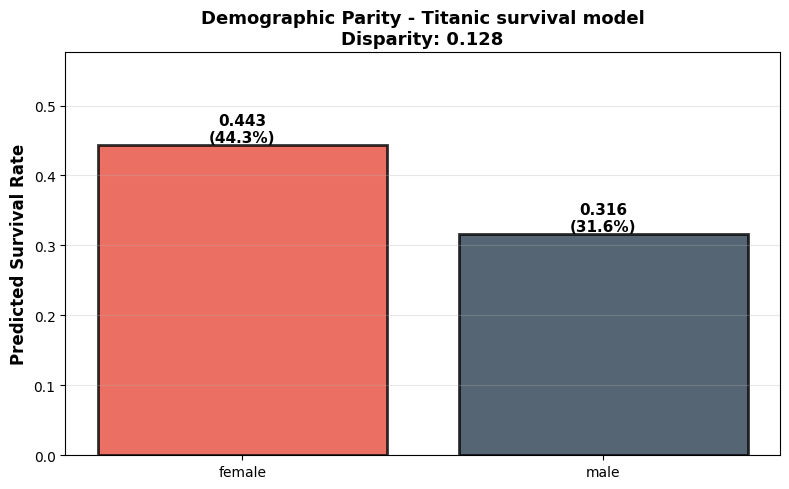

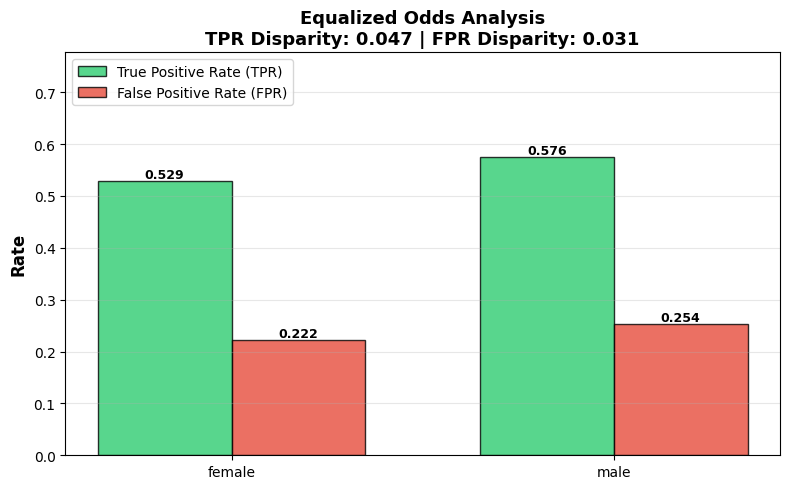

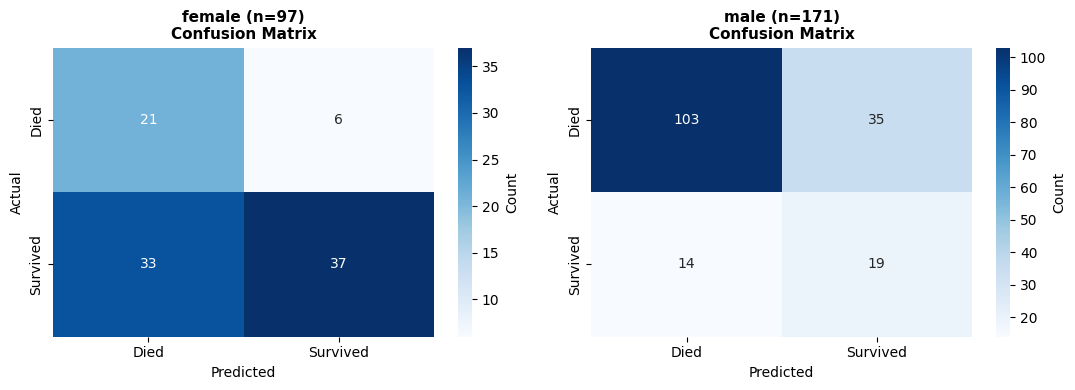

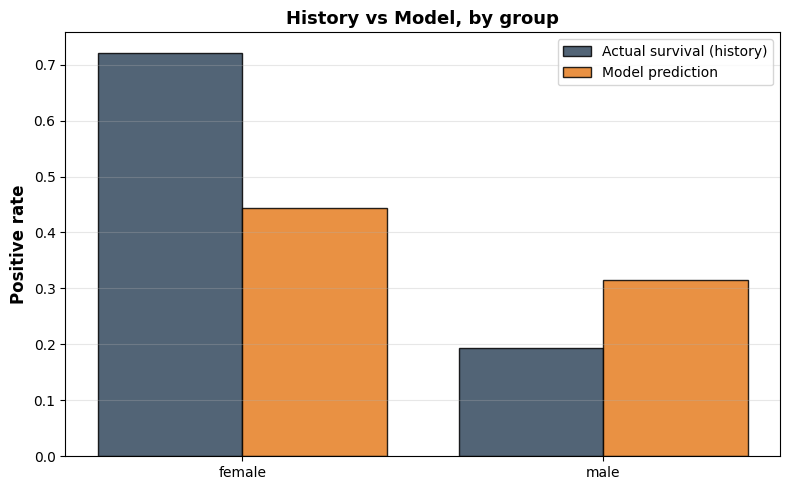

WHAT THE CHARTS ACTUALLY SHOW (numbers computed from this run):
1. The groups receive positive predictions at clearly different rates
   (demographic parity disparity 0.128) - even though the
   model never received the 'Sex' column. Proxies carried the signal.
2. The error profiles are comparatively close (TPR disparity
   0.047, FPR disparity 0.031) - so this model
   is NOT obviously unfair by equalized odds, even though demographic
   parity flagged it. Different metrics, different verdicts.
3. Chart 4 is the uncomfortable one: history recorded 0.722 vs 0.193 survival across the
   two groups, but the blinded model predicted only 0.443 vs 0.316. It UNDER-predicts survival
   for the group that actually survived most - which is exactly why its
   accuracy for that group (0.598) is the worst in the table.

4. THE LESSON: real data does not produce a tidy 'group B is penalized'
   story. Metrics disagreed with each other here. Fairness auditing is
   about reporting several metrics ho

In [6]:
# Step 5: Visualize the bias detection results
# Three views: demographic parity, equalized odds, per-group confusion matrices

# --- Chart 1: Demographic parity ---
groups = list(parity_rates.keys())
rates = list(parity_rates.values())
fig, ax = plt.subplots(figsize=(8, 5))
# One colour per group, used identically in every notebook of this unit:
# female = red, male = dark slate. 'groups' is sorted, so female comes first.
GROUP_COLORS = {'female': '#e74c3c', 'male': '#2c3e50'}
bars = ax.bar(groups, rates, color=[GROUP_COLORS[g] for g in groups], alpha=0.8,
              edgecolor='black', linewidth=2)
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
            f'{rate:.3f}\n({rate*100:.1f}%)', ha='center', va='bottom',
            fontweight='bold', fontsize=11)
ax.set_ylabel('Predicted Survival Rate', fontsize=12, fontweight='bold')
ax.set_title(f'Demographic Parity - Titanic survival model\nDisparity: {parity_disparity:.3f}',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(rates) * 1.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 2: Equalized odds ---
tprs = [equalized_odds[g]['TPR'] for g in groups]
fprs = [equalized_odds[g]['FPR'] for g in groups]
x = np.arange(len(groups))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, tprs, width, label='True Positive Rate (TPR)',
            color='#2ecc71', alpha=0.8, edgecolor='black')
b2 = ax.bar(x + width/2, fprs, width, label='False Positive Rate (FPR)',
            color='#e74c3c', alpha=0.8, edgecolor='black')
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel('Rate', fontsize=12, fontweight='bold')
ax.set_title(f'Equalized Odds Analysis\nTPR Disparity: {tpr_disparity:.3f} | '
             f'FPR Disparity: {fpr_disparity:.3f}', fontsize=13, fontweight='bold')
# Headroom so the legend cannot sit on top of a bar and hide it.
ax.set_ylim(0, max(tprs + fprs) * 1.35)
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- Chart 3: Confusion matrices by group ---
uniq = sorted(test_df['group'].unique())
fig, axes = plt.subplots(1, len(uniq), figsize=(11, 4))
for idx, group in enumerate(uniq):
    gd = test_df[test_df['group'] == group]
    cm = confusion_matrix(gd['Survived'], gd['predicted'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{group} (n={len(gd)})\nConfusion Matrix',
                        fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted'); axes[idx].set_ylabel('Actual')
    axes[idx].set_xticklabels(['Died', 'Survived'])
    axes[idx].set_yticklabels(['Died', 'Survived'])
plt.tight_layout()
plt.show()

# --- Chart 4: what the model was ASKED to predict vs what it DID predict ---
# Real data lets us compare the model's behaviour to the historical record itself.
actual_rate = test_df.groupby('group')['Survived'].mean()
pred_rate = test_df.groupby('group')['predicted'].mean()
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(actual_rate))
ax.bar(x - 0.2, actual_rate.values, 0.4, label='Actual survival (history)',
       color='#34495e', alpha=0.85, edgecolor='black')
ax.bar(x + 0.2, pred_rate.values, 0.4, label='Model prediction',
       color='#e67e22', alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(actual_rate.index)
ax.set_ylabel('Positive rate', fontsize=12, fontweight='bold')
ax.set_title('History vs Model, by group', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Data-driven reading of the charts (computed, not assumed):
print("WHAT THE CHARTS ACTUALLY SHOW (numbers computed from this run):")
if parity_disparity > 0.1:
    print(f"1. The groups receive positive predictions at clearly different rates")
    print(f"   (demographic parity disparity {parity_disparity:.3f}) - even though the")
    print(f"   model never received the 'Sex' column. Proxies carried the signal.")
else:
    print(f"1. Overall positive-prediction rates look similar")
    print(f"   (demographic parity disparity only {parity_disparity:.3f}).")

if tpr_disparity > 0.1 or fpr_disparity > 0.1:
    print(f"2. The ERROR profiles also differ (TPR disparity {tpr_disparity:.3f},")
    print(f"   FPR disparity {fpr_disparity:.3f}) - see the confusion matrices.")
else:
    print(f"2. The error profiles are comparatively close (TPR disparity")
    print(f"   {tpr_disparity:.3f}, FPR disparity {fpr_disparity:.3f}) - so this model")
    print(f"   is NOT obviously unfair by equalized odds, even though demographic")
    print(f"   parity flagged it. Different metrics, different verdicts.")

print(f"3. Chart 4 is the uncomfortable one: history recorded "
      f"{actual_rate.max():.3f} vs {actual_rate.min():.3f} survival across the")
print(f"   two groups, but the blinded model predicted only "
      f"{pred_rate.max():.3f} vs {pred_rate.min():.3f}. It UNDER-predicts survival")
print(f"   for the group that actually survived most - which is exactly why its")
print(f"   accuracy for that group ({accs[worst]:.3f}) is the worst in the table.")
print("\n4. THE LESSON: real data does not produce a tidy 'group B is penalized'")
print("   story. Metrics disagreed with each other here. Fairness auditing is")
print("   about reporting several metrics honestly, then arguing about which one")
print("   the situation demands - not about finding a single number that passes.")

## Part 6: Fairness Is a Dial, Not a Property of the Model

Every number in Part 4 and every chart in Part 5 was computed at one hidden setting:
`model.predict()` cuts at a probability of **0.50**. Nobody chose that on fairness
grounds — it is a library default.

So before you write "this model is biased" in a report, ask the question the audit
above never asked: **what happens to those metrics if the cut-off moves?** Below we
freeze the model, the data and the test split, and turn only that one dial. The top
row is a five-frame storyboard of the same picture at five settings; the bottom row
tracks the metrics continuously across the whole range.

---

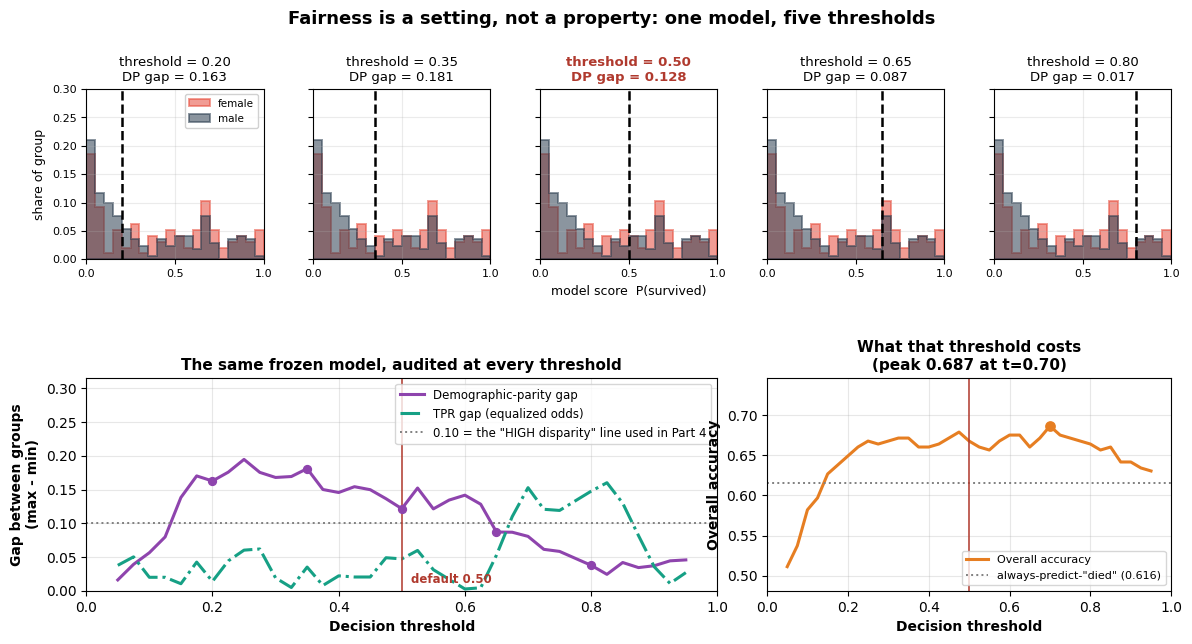

STEP TABLE (same model, same test set, only the threshold changes)
 threshold   female rate     male rate   DP gap  TPR gap  accuracy
------------------------------------------------------------------
      0.20         0.660         0.497    0.163    0.014     0.649
      0.35         0.567         0.386    0.181    0.035     0.672
      0.50         0.443         0.316    0.128    0.047     0.672
      0.65         0.309         0.222    0.087    0.053     0.660
      0.80         0.134         0.117    0.017    0.176     0.657

WHAT THE STORYBOARD SHOWS (computed, not assumed):
1. The demographic-parity gap is not a property of the model. Across the
   sweep it runs from 0.016 to 0.195 (worst at
   threshold 0.25) while the model, the data and the split never
   change. Only the cut-off moves.
2. The 0.50 frame reproduces Part 4 exactly: DP gap 0.128.
   That row of the audit was a choice of cut-off, not a verdict on the model.
3. Both ends of the dial shrink the gap, because the de

In [7]:
# Why a sweep: "is this model fair?" is not answerable until you say WHERE the
# decision threshold sits. Below we never retrain - the model, the data and the
# test split are frozen. Only the cut-off moves. This is the storyboard form of
# an animation: five frames of the same picture at five settings of one dial.

# Recover the held-out feature matrix: test_df is X_test plus three added columns.
feat_cols = [c for c in test_df.columns
             if c not in ('Survived', 'predicted', 'group')]
proba = model.predict_proba(test_df[feat_cols])[:, 1]   # P(survived), per passenger
grp = test_df['group'].values
truth = test_df['Survived'].values
g_names = sorted(set(grp))                              # ['female', 'male']

# Use strict '>' so that t = 0.50 reproduces sklearn's own predict() exactly -
# the numbers in the 0.50 frame must match the audit you already ran in Part 4.
def metrics_at(t):
    """Positive rates per group, DP gap, TPR gap and accuracy at cut-off t."""
    pred_t = (proba > t).astype(int)
    rates = [pred_t[grp == g].mean() for g in g_names]
    tprs_t = [pred_t[(grp == g) & (truth == 1)].mean() for g in g_names]
    return (rates, max(rates) - min(rates), max(tprs_t) - min(tprs_t),
            (pred_t == truth).mean(), pred_t.mean())

ts = np.linspace(0.05, 0.95, 37)
dp_curve, tpr_curve, acc_curve, pos_curve = [], [], [], []
for t in ts:
    _, dp_t, tpr_t, acc_t, pos_t = metrics_at(t)
    dp_curve.append(dp_t); tpr_curve.append(tpr_t)
    acc_curve.append(acc_t); pos_curve.append(pos_t)

# Five storyboard frames, including the default 0.50 the model actually used.
frames = [0.20, 0.35, 0.50, 0.65, 0.80]
colors_g = GROUP_COLORS          # same palette as the charts in Part 5

fig = plt.figure(figsize=(14, 6.6))
gs = fig.add_gridspec(2, 5, height_ratios=[1, 1.25], hspace=0.62, wspace=0.28,
                      top=0.86, bottom=0.10)

bins = np.linspace(0, 1, 21)
for k, t in enumerate(frames):
    ax = fig.add_subplot(gs[0, k])
    for g in g_names:
        vals = proba[grp == g]
        # Weight each group to sum to 1 so the smaller group stays visible.
        ax.hist(vals, bins=bins, weights=np.full(len(vals), 1 / len(vals)),
                histtype='stepfilled', alpha=0.55, color=colors_g[g],
                edgecolor=colors_g[g], linewidth=1.4, label=g)
    ax.axvline(t, color='black', linestyle='--', linewidth=1.8)
    _, gap, _, _, _ = metrics_at(t)
    ax.set_title(f'threshold = {t:.2f}\nDP gap = {gap:.3f}', fontsize=9.5,
                 fontweight='bold' if t == 0.50 else 'normal',
                 color='#b03a2e' if t == 0.50 else 'black')
    ax.set_xlim(0, 1); ax.set_ylim(0, 0.30)
    ax.set_xticks([0, 0.5, 1]); ax.tick_params(labelsize=8)
    if k == 0:
        ax.set_ylabel('share of group', fontsize=9)
        ax.legend(fontsize=7.5, loc='upper right', framealpha=0.9)
    else:
        ax.set_yticklabels([])
    if k == 2:
        ax.set_xlabel('model score  P(survived)', fontsize=9)
    ax.grid(alpha=0.25)

# Bottom-left: how the two fairness gaps move as the dial turns.
axl = fig.add_subplot(gs[1, 0:3])
axl.plot(ts, dp_curve, color='#8e44ad', linewidth=2.2,
         label='Demographic-parity gap')
axl.plot(ts, tpr_curve, color='#16a085', linewidth=2.2, linestyle='-.',
         label='TPR gap (equalized odds)')
axl.axhline(0.1, color='grey', linestyle=':', linewidth=1.4,
            label='0.10 = the "HIGH disparity" line used in Part 4')
axl.axvline(0.5, color='#b03a2e', linewidth=1.4, alpha=0.8)
axl.scatter(frames, [dp_curve[int(np.argmin(abs(ts - t)))] for t in frames],
            color='#8e44ad', zorder=5, s=32)
ymax = max(max(dp_curve), max(tpr_curve))
axl.text(0.515, 0.012, 'default 0.50', fontsize=8.5, color='#b03a2e',
         fontweight='bold')
axl.set_xlabel('Decision threshold', fontsize=10, fontweight='bold')
axl.set_ylabel('Gap between groups\n(max - min)', fontsize=10, fontweight='bold')
axl.set_title('The same frozen model, audited at every threshold',
              fontsize=11, fontweight='bold')
axl.set_xlim(0, 1); axl.set_ylim(0, ymax * 1.62)
axl.legend(fontsize=8.5, loc='upper right'); axl.grid(alpha=0.3)

# Bottom-right: what each threshold costs in accuracy.
axr = fig.add_subplot(gs[1, 3:5])
majority_acc = max(truth.mean(), 1 - truth.mean())
axr.plot(ts, acc_curve, color='#e67e22', linewidth=2.2, label='Overall accuracy')
axr.axhline(majority_acc, color='grey', linestyle=':', linewidth=1.4,
            label=f'always-predict-"died" ({majority_acc:.3f})')
axr.axvline(0.5, color='#b03a2e', linewidth=1.4, alpha=0.8)
best_t = ts[int(np.argmax(acc_curve))]
axr.scatter([best_t], [max(acc_curve)], color='#e67e22', s=45, zorder=5)
axr.set_xlabel('Decision threshold', fontsize=10, fontweight='bold')
axr.set_ylabel('Overall accuracy', fontsize=10, fontweight='bold')
axr.set_title(f'What that threshold costs\n(peak {max(acc_curve):.3f} at t={best_t:.2f})',
              fontsize=11, fontweight='bold')
axr.set_xlim(0, 1); axr.set_ylim(min(acc_curve) - 0.03, max(acc_curve) + 0.06)
axr.legend(fontsize=8, loc='lower right'); axr.grid(alpha=0.3)

fig.suptitle('Fairness is a setting, not a property: one model, five thresholds',
             fontsize=13, fontweight='bold')
plt.show()

# The step table behind the storyboard - the numbers under each frame.
print("STEP TABLE (same model, same test set, only the threshold changes)")
head = f"{'threshold':>10}{g_names[0] + ' rate':>14}{g_names[1] + ' rate':>14}"
head += f"{'DP gap':>9}{'TPR gap':>9}{'accuracy':>10}"
print(head)
print("-" * len(head))
for t in frames:
    r, dp_t, tpr_t, acc_t, _ = metrics_at(t)
    print(f"{t:>10.2f}{r[0]:>14.3f}{r[1]:>14.3f}"
          f"{dp_t:>9.3f}{tpr_t:>9.3f}{acc_t:>10.3f}")

# Data-driven reading (every number below is computed from the run above).
i_worst = int(np.argmax(dp_curve))
i_best_acc = int(np.argmax(acc_curve))
i_min_dp = int(np.argmin(dp_curve))
print("\nWHAT THE STORYBOARD SHOWS (computed, not assumed):")
print(f"1. The demographic-parity gap is not a property of the model. Across the")
print(f"   sweep it runs from {min(dp_curve):.3f} to {max(dp_curve):.3f} (worst at")
print(f"   threshold {ts[i_worst]:.2f}) while the model, the data and the split never")
print(f"   change. Only the cut-off moves.")
print(f"2. The 0.50 frame reproduces Part 4 exactly: DP gap {parity_disparity:.3f}.")
print(f"   That row of the audit was a choice of cut-off, not a verdict on the model.")
print(f"3. Both ends of the dial shrink the gap, because the decision collapses")
print(f"   toward one answer for everybody: at t={ts[0]:.2f} the model says 'survived'")
print(f"   for {pos_curve[0]:.0%} of the test set (gap {dp_curve[0]:.3f}, accuracy "
      f"{acc_curve[0]:.3f}")
print(f"   - WORSE than the {majority_acc:.3f} you get by predicting 'died' for all),")
print(f"   and at t={ts[-1]:.2f} for {pos_curve[-1]:.0%} (gap {dp_curve[-1]:.3f}, "
      f"accuracy {acc_curve[-1]:.3f}).")
print(f"4. The smallest gap in the whole sweep ({min(dp_curve):.3f}) sits at threshold")
print(f"   {ts[i_min_dp]:.2f}, where accuracy is {acc_curve[i_min_dp]:.3f}; the best")
print(f"   accuracy ({max(acc_curve):.3f}) sits at {ts[i_best_acc]:.2f}, where the gap is")
print(f"   {dp_curve[i_best_acc]:.3f}. The fairest setting and the most accurate setting")
print(f"   are not the same setting - somebody has to choose, and say so out loud.")
print(f"5. The two gap curves peak in different places ({ts[i_worst]:.2f} for parity,")
print(f"   {ts[int(np.argmax(tpr_curve))]:.2f} for TPR). The disagreement between metrics")
print(f"   from Part 4 is now visible as two curves of different shape.")

### 🔍 How to read the storyboard

- **Top row, five frames.** Each frame draws the *same* two score distributions — one
  filled histogram per group — with a dashed line marking where the cut-off sits.
  The distributions are identical in all five frames; only the dashed line moves.
  Everyone to the **right** of the line is predicted "survived".
- **Frame 3 has a red title because 0.50 is the setting that produced every chart in
  Part 5.** Its DP gap matches the audit number from Part 4 exactly. That number was a
  choice of cut-off, not a verdict on the model.
- **Bottom left.** The purple parity curve and the green TPR curve are different shapes
  and peak in different places. That is the "two metrics, two verdicts" problem drawn as
  a picture: whether the model crosses the dotted 0.10 warning line depends on the dial,
  and the two metrics do not cross it in the same place.
- **Bottom right — never read the left panel without this one.** The gaps shrink toward
  the edges of the dial, and the accuracy curve shows the price: at the far left it drops
  *below* the dotted line, which is the accuracy of a model that predicts "died" for every
  passenger and never looks at the data at all.

**What it proves:** a fairness metric describes a *deployed decision rule*, not a trained
model. The exact numbers under each frame are printed in the step table above — quote the
threshold with the metric, or the metric cannot be read.

---

## 💬 Discuss

Argue from the numbers **your own run** just printed, not from principle: demographic-parity
disparity **0.128** (flagged HIGH), TPR disparity **0.047**, FPR disparity **0.031**,
per-group accuracy worst (**0.598**) for the group that historically survived most, overall
accuracy **0.672** — and the model **never received the `Sex` column**.

1. **Two metrics, two verdicts, one model.** Demographic parity says this model is unfair.
   Equalized odds says it is roughly fine. You have to write one sentence at the top of a
   report that a manager will read and nobody will read past. Which metric do you lead with,
   and what evidence would make you switch? You may not dodge by reporting both without
   ranking them — the reader's next question is always "so which one decides?"
2. **Is not collecting the attribute a defence or an admission?** Your model reconstructed
   the group split from fare, ticket class and family size. So "we do not collect sex" did
   not prevent the split — but note the trap: if you do not collect it, you also cannot
   compute the table above. Under **EU AI Act Article 10(5)**, providers of high-risk systems
   *may exceptionally* process special-category data specifically to detect and correct bias,
   under strict safeguards. Should collecting race or sex **for audit only** be mandatory for
   hiring systems in your country? Who is allowed to hold that file, and what happens the
   day it leaks?
3. **Disparity is not automatically discrimination.** "Women and children first" was a stated
   evacuation policy, so part of the 55.3-point gap is a policy working as designed.
   Obermeyer's cost gap was not designed by anyone. The same `groupby` produces both numbers.
   What evidence — not intuition — would let you tell an intended disparity from a
   discriminatory one? And who in an organisation should be allowed to make that call: the
   ML team, legal, or the affected group?


## ⚠️ Where this breaks

Everything above is a measurement, and every measurement has preconditions.

- **You cannot audit a group you did not record.** This notebook works because the manifest
  has a `Sex` column. Most production systems do not record race, disability or religion —
  often for good privacy reasons — and then the audit is simply not possible. Proxy methods
  exist (surname-and-geography imputation, e.g. BISG, used by US fair-lending regulators) and
  they carry their own error rates, which flow straight into your fairness estimate and are
  rarely reported alongside it.
- **The metrics are mathematically forced to disagree — this is not a bug in your code.**
  Chouldechova (2017) and Kleinberg, Mullainathan & Raghavan (2016) proved that when two
  groups have different base rates, calibration and equal error rates cannot both hold. Your
  run showed the mild version. Expect it every time. Anyone selling a model that is "fair on
  all metrics" is either not measuring or not telling you.
- **Small groups give unstable numbers.** The female test group here is **n = 97**. A handful
  of passengers crossing the decision threshold visibly moves the rates. Report group sizes
  and uncertainty with every fairness metric or you will spend your career chasing noise —
  Notebook 05 measures exactly this instability across 15 independent draws.
- **The label itself can be the bias, and no metric here will notice.** Obermeyer's algorithm
  had no measurement problem; it had a *target* problem. If your `y` is a proxy — cost for
  illness, arrest for crime, clicks for quality, tenure for performance — every metric in
  this notebook will faithfully confirm that the model predicts the proxy well, and none of
  them will tell you the proxy is wrong.
- **A metric measures; it does not judge.** Nothing here decides whether a disparity is
  acceptable. That is a human decision and it needs a named person's signature on it
  (Unit 4).

**The cheaper alternative when a full audit is not warranted:** for a low-stakes system, a
per-group accuracy table *with group sizes* — three lines of `groupby` — catches most real
problems and costs nothing. Escalate to the full metric suite when the decision touches
someone's liberty, money, health or employment.


## 🎯 Summary: What We Learned

**BEFORE this notebook**: We knew bias exists but didn't know how to detect it in our models.

**AFTER this notebook**: We can:
- ✅ Audit a **real** dataset (891 Titanic passengers) for group disparity
- ✅ Handle real missingness honestly before auditing (and say what we imputed)
- ✅ Calculate fairness metrics (demographic parity, equalized odds, per-group accuracy)
- ✅ Train ML models and detect disparity in their predictions
- ✅ Visualize bias using charts and confusion matrices
- ✅ Interpret bias detection results **when the metrics disagree**

### Key Takeaways

1. **Multiple Metrics Matter**: Different fairness metrics reveal different types of
   disparity - and on real data they routinely return different verdicts on the
   SAME model. Run the cells above and read which ones fired.
2. **Fairness Through Unawareness Fails**: our model never received the `Sex`
   column and still split its predictions by group, because fare, ticket class and
   family size act as proxies. Deleting a protected attribute is not a mitigation.
3. **Report Per Group, Never Only In Aggregate**: the overall accuracy hid a
   clear per-group accuracy gap.
4. **Disparity ≠ Proven Discrimination**: "women and children first" was a stated
   policy. A metric detects that outcomes differ; only human judgment decides
   whether that difference is justified. Real data forces this distinction.
5. **Visualization Helps**: charts make disparity patterns easier to communicate.

---

## 🚫 When Bias Detection Hits a Limitation

### The Limitation We Discovered

We've learned how to detect bias in AI systems using metrics like demographic parity and equalized odds. **But there's a critical problem:**

**We detected disparity, but how do we fix it?**

Bias detection tells us:
- ✅ Where disparity exists
- ✅ How large it is
- ✅ Which groups are affected

**But it doesn't tell us:**
- ❌ How to **reduce** the disparity
- ❌ How to **mitigate** unfairness
- ❌ How to **fix** the model

### Why This Is a Problem

When we detect bias but can't fix it:
- We know there's a problem but can't solve it
- Unfair systems continue to operate
- Affected groups continue to be disadvantaged
- Detection alone isn't enough

### The Solution: Bias Mitigation

We need **bias mitigation techniques** to:
1. Reduce disparity in models
2. Make systems fairer across groups
3. Fix the problems we detected

**This is exactly what we'll learn in the next notebook: Bias Mitigation!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to detect bias using fairness metrics on real data
- ✅ How to visualize disparity patterns
- ✅ **The limitation**: Detection isn't enough - we need to fix it!

**Next notebook**: `02_bias_mitigation.ipynb`
- Learn how to mitigate bias using pre-processing, in-processing, and post-processing
- Work on the SAME real Titanic data, so you can see what actually changes
- Make models fairer across groups

**Congratulations!** 🎉 You've learned how to detect bias in machine learning models systematically!

## 🔭 State of the field (2026)

The audit you just ran by hand is, in 2026, something a team is expected to **report**, not
merely to perform, and two things moved to get there. **The choice of metric became something
you must justify.** A 2025 scoping review of clinical predictive AI extracted **62 distinct
fairness metrics from 41 studies** and reported real gaps in how those metrics are validated
against the decision they are supposed to govern — which is the "two metrics, two verdicts"
problem of Part 4 playing out across an entire literature. **And auditing without the grouping
column became its own method:** where the protected attribute was never recorded, current
dataset audits *infer* it with a model and then apply a statistical test designed to absorb the
imprecision of that inference, rather than quietly treating the inferred label as truth.

Neither development replaces what this notebook teaches — both are built on it. Demographic
parity, equalized odds and a per-group accuracy table are the **mechanism** those pipelines
automate, and the threshold sweep in Part 6 is precisely why a modern audit report is expected
to quote the operating point next to the number. Learn the three-line `groupby` first: it is
what the official plan examines, and it is still the thing that finds the disparity.

- Matos, J., Van Calster, B., Celi, L. A., et al. (2025). *Critical Appraisal of Fairness Metrics in Clinical Predictive AI*. <https://arxiv.org/abs/2506.17035>
- Lafargue, V., Claeys, E. & Loubes, J.-M. (2025). *Fairness is in the details: Face Dataset Auditing*. ECML PKDD 2025. <https://arxiv.org/abs/2504.08396>

---


## 📚 References

1. Dwork, C., Hardt, M., Pitassi, T., Reingold, O. & Zemel, R. (2012). *Fairness Through Awareness*. ITCS 2012. <https://arxiv.org/abs/1104.3913>
2. Hardt, M., Price, E. & Srebro, N. (2016). *Equality of Opportunity in Supervised Learning*. NeurIPS 2016. <https://arxiv.org/abs/1610.02413>
3. Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K. & Galstyan, A. (2021). *A Survey on Bias and Fairness in Machine Learning*. ACM Computing Surveys, 54(6). <https://arxiv.org/abs/1908.09635>
4. Barocas, S., Hardt, M. & Narayanan, A. (2023). *Fairness and Machine Learning: Limitations and Opportunities*. MIT Press. <https://fairmlbook.org/>
5. Matos, J., Van Calster, B., Celi, L. A., Dhiman, P., Gichoya, J. W., Riley, R. D., Russell, C., Khalid, S. & Collins, G. S. (2025). *Critical Appraisal of Fairness Metrics in Clinical Predictive AI*. arXiv:2506.17035. <https://arxiv.org/abs/2506.17035> — a scoping review that extracted **62 distinct fairness metrics from 41 studies** and reports gaps in how those metrics are validated for real clinical use: the "two metrics, two verdicts" problem of Part 4 at the scale of a whole literature.
6. Lafargue, V., Claeys, E. & Loubes, J.-M. (2025). *Fairness is in the details: Face Dataset Auditing*. ECML PKDD 2025, LNCS 16022, Springer. <https://arxiv.org/abs/2504.08396> — how to audit when the protected attribute was never recorded: infer it with a model, then use a statistical test built to absorb the imprecision of that inference (the gap named in ⚠️ *Where this breaks*).
